# Week 13: CCE Spikes Predict Hallucination

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniJani/reposynth/blob/Research/research/Week13_CCE_Error_Correlation.ipynb)

## Goal

**Prove that CCE (Code-Conditional Entropy) spikes during LLM generation predict when the model will hallucinate or make errors.**

### Hypothesis

When a language model has high entropy (CCE spike) at a token position, it is uncertain. This uncertainty correlates with higher probability of generating incorrect/hallucinated content.

### Experiment Design

```
Phase 1: Generate answers WITHOUT retrieval, record CCE at each token
Phase 2: Evaluate correctness of generated answers
Phase 3: Compute correlation: CCE vs Error
Phase 4: Test if CCE-triggered retrieval reduces errors
```

### Why This Matters

If CCE predicts errors:
- We can trigger retrieval ONLY when needed (efficient)
- We can warn users about uncertain regions
- We validate CCE as a meaningful uncertainty signal

## 1. Setup

In [1]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scipy numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 44.9 MB/s eta 0:00:00


In [2]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
!nvidia-smi

Device: cuda
Wed Feb  4 22:33:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       5MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------------

## 2. Clone Target Repository

In [3]:
# Clone httpx as our target repo
REPO_URL = 'https://github.com/encode/httpx.git'
REPO_DIR = '/content/httpx'

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print("Repository already exists")

!ls {REPO_DIR}

Cloning into '/content/httpx'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 140 (delta 2), reused 47 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 2.21 MiB | 16.53 MiB/s, done.
Resolving deltas: 100% (2/2), done.
CHANGELOG.md  httpx	  mkdocs.yml	  README.md	    scripts
docs	      LICENSE.md  pyproject.toml  requirements.txt  tests


In [4]:
# Load source files for verification
def load_source_files(repo_dir: str, src_folder: str = 'httpx') -> Dict[str, str]:
    """Load all Python files from the source folder."""
    files = {}
    src_path = os.path.join(repo_dir, src_folder)

    for root, _, filenames in os.walk(src_path):
        for fname in filenames:
            if fname.endswith('.py'):
                fpath = os.path.join(root, fname)
                rel_path = os.path.relpath(fpath, repo_dir)
                try:
                    with open(fpath, 'r', encoding='utf-8') as f:
                        files[rel_path] = f.read()
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

    return files

SOURCE_FILES = load_source_files(REPO_DIR)
print(f"Loaded {len(SOURCE_FILES)} source files")
for f in list(SOURCE_FILES.keys())[:5]:
    print(f"  {f}")

Loaded 23 source files
  httpx/__init__.py
  httpx/_api.py
  httpx/_models.py
  httpx/_exceptions.py
  httpx/_auth.py


## 3. Load Language Model

In [5]:
# Load CodeLlama with 4-bit quantization
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

print(f"Loading {MODEL_NAME}...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

Loading codellama/CodeLlama-7b-Instruct-hf...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!


## 4. Define Factual Questions with Ground Truth

These questions have **objective, verifiable answers** from the source code.

In [6]:
# Factual questions with verifiable ground truth
FACTUAL_BENCHMARK = [
    {
        'id': 'fact_001',
        'question': 'What is the default timeout value in httpx?',
        'ground_truth': '5.0 seconds',
        'verification_file': 'httpx/_config.py',
        'verification_pattern': 'DEFAULT_TIMEOUT_CONFIG',
        'key_facts': ['5.0', 'seconds', 'Timeout'],
    },
    {
        'id': 'fact_002',
        'question': 'What HTTP methods does httpx support for requests?',
        'ground_truth': 'GET, POST, PUT, DELETE, PATCH, HEAD, OPTIONS',
        'verification_file': 'httpx/_api.py',
        'key_facts': ['get', 'post', 'put', 'delete', 'patch', 'head', 'options'],
    },
    {
        'id': 'fact_003',
        'question': 'What exception does httpx raise for HTTP error status codes?',
        'ground_truth': 'HTTPStatusError',
        'verification_file': 'httpx/_exceptions.py',
        'key_facts': ['HTTPStatusError', 'raise_for_status'],
    },
    {
        'id': 'fact_004',
        'question': 'What class does httpx use for handling authentication?',
        'ground_truth': 'Auth base class with BasicAuth, DigestAuth subclasses',
        'verification_file': 'httpx/_auth.py',
        'key_facts': ['Auth', 'BasicAuth', 'DigestAuth'],
    },
    {
        'id': 'fact_005',
        'question': 'What is the main client class in httpx for synchronous requests?',
        'ground_truth': 'Client',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['Client', 'class Client'],
    },
    {
        'id': 'fact_006',
        'question': 'What is the main client class in httpx for asynchronous requests?',
        'ground_truth': 'AsyncClient',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['AsyncClient', 'async', 'await'],
    },
    {
        'id': 'fact_007',
        'question': 'How does httpx handle response content decoding?',
        'ground_truth': 'Uses Decoder classes like TextDecoder, GZipDecoder, BrotliDecoder',
        'verification_file': 'httpx/_decoders.py',
        'key_facts': ['Decoder', 'GZipDecoder', 'BrotliDecoder', 'TextDecoder'],
    },
    {
        'id': 'fact_008',
        'question': 'What parameter controls redirect following in httpx?',
        'ground_truth': 'follow_redirects parameter (boolean)',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['follow_redirects', 'redirect'],
    },
    {
        'id': 'fact_009',
        'question': 'What exception does httpx raise for connection errors?',
        'ground_truth': 'ConnectError',
        'verification_file': 'httpx/_exceptions.py',
        'key_facts': ['ConnectError', 'connection'],
    },
    {
        'id': 'fact_010',
        'question': 'How do you set custom headers in an httpx request?',
        'ground_truth': 'Pass headers parameter as dict to request method or Client',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['headers', 'dict', 'Headers'],
    },
    {
        'id': 'fact_011',
        'question': 'What is the default User-Agent header in httpx?',
        'ground_truth': 'python-httpx/{version}',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['python-httpx', 'User-Agent', 'user-agent'],
    },
    {
        'id': 'fact_012',
        'question': 'What exception does httpx raise when a request times out?',
        'ground_truth': 'TimeoutException or specific subclasses like ConnectTimeout, ReadTimeout',
        'verification_file': 'httpx/_exceptions.py',
        'key_facts': ['TimeoutException', 'ConnectTimeout', 'ReadTimeout', 'Timeout'],
    },
    {
        'id': 'fact_013',
        'question': 'How does httpx handle cookies between requests?',
        'ground_truth': 'Client maintains a cookies jar; can also pass cookies parameter',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['cookies', 'Cookies', 'jar'],
    },
    {
        'id': 'fact_014',
        'question': 'What transport does httpx use by default for HTTP/1.1?',
        'ground_truth': 'HTTPTransport (httpcore-based)',
        'verification_file': 'httpx/_transports/default.py',
        'key_facts': ['HTTPTransport', 'httpcore', 'transport'],
    },
    {
        'id': 'fact_015',
        'question': 'How do you enable HTTP/2 in httpx?',
        'ground_truth': 'Set http2=True when creating Client',
        'verification_file': 'httpx/_client.py',
        'key_facts': ['http2', 'True', 'HTTP/2'],
    },
    {
        'id': 'fact_016',
        'question': 'What class represents an HTTP response in httpx?',
        'ground_truth': 'Response',
        'verification_file': 'httpx/_models.py',
        'key_facts': ['Response', 'class Response'],
    },
    {
        'id': 'fact_017',
        'question': 'What class represents an HTTP request in httpx?',
        'ground_truth': 'Request',
        'verification_file': 'httpx/_models.py',
        'key_facts': ['Request', 'class Request'],
    },
    {
        'id': 'fact_018',
        'question': 'What method streams response content in httpx?',
        'ground_truth': 'iter_bytes(), iter_text(), iter_lines(), or stream()',
        'verification_file': 'httpx/_models.py',
        'key_facts': ['iter_bytes', 'iter_text', 'iter_lines', 'stream'],
    },
    {
        'id': 'fact_019',
        'question': 'How do you send form data in httpx POST request?',
        'ground_truth': 'Use data parameter with dict for form-encoded data',
        'verification_file': 'httpx/_content.py',
        'key_facts': ['data', 'form', 'urlencoded'],
    },
    {
        'id': 'fact_020',
        'question': 'How do you send JSON data in httpx POST request?',
        'ground_truth': 'Use json parameter with dict',
        'verification_file': 'httpx/_content.py',
        'key_facts': ['json', 'application/json'],
    },
]

print(f"Defined {len(FACTUAL_BENCHMARK)} factual questions with ground truth")

Defined 20 factual questions with ground truth


## 5. CCE Computation and Generation

In [7]:
@dataclass
class GenerationTrace:
    """Records CCE and tokens during generation."""
    question_id: str
    question: str
    tokens: List[int] = field(default_factory=list)
    token_strings: List[str] = field(default_factory=list)
    cce_values: List[float] = field(default_factory=list)
    generated_text: str = ""

    def get_spike_positions(self, threshold: float = 3.0) -> List[int]:
        """Get positions where CCE exceeds threshold."""
        return [i for i, cce in enumerate(self.cce_values) if cce > threshold]

    def get_mean_cce(self) -> float:
        return np.mean(self.cce_values) if self.cce_values else 0.0

    def get_max_cce(self) -> float:
        return np.max(self.cce_values) if self.cce_values else 0.0


def generate_with_cce_trace(
    model,
    tokenizer,
    prompt: str,
    max_tokens: int = 150,
    temperature: float = 0.7,
    cce_threshold: float = 3.0,
) -> GenerationTrace:
    """Generate text and record CCE at each token position.

    CCE (Code-Conditional Entropy) is computed in BITS (log base 2) on the
    RAW logits (no temperature scaling) to match the original implementation.
    """

    trace = GenerationTrace(
        question_id="",
        question=prompt,
    )

    # Encode prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        for step in range(max_tokens):
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :].float()  # Convert to float32

            # ============================================
            # FIXED CCE COMPUTATION
            # ============================================
            # 1. Use RAW logits (no temperature) for CCE
            # 2. Use log base 2 (bits) not natural log (nats)
            # 3. This matches the original CCE spike detection

            probs_for_cce = F.softmax(logits, dim=-1)  # NO temperature!

            # Entropy in BITS (log base 2)
            log2_probs = torch.log2(probs_for_cce + 1e-10)
            entropy_bits = -(probs_for_cce * log2_probs).sum(dim=-1).item()

            trace.cce_values.append(entropy_bits)

            # For SAMPLING, use temperature
            probs_for_sampling = F.softmax(logits / temperature, dim=-1)

            # Sample next token
            if temperature > 0:
                next_token = torch.multinomial(probs_for_sampling, num_samples=1)
            else:
                next_token = torch.argmax(probs_for_sampling, dim=-1, keepdim=True)

            trace.tokens.append(next_token.item())
            trace.token_strings.append(tokenizer.decode([next_token.item()]))

            # Update input
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            # Stop at EOS
            if next_token.item() == tokenizer.eos_token_id:
                break

    trace.generated_text = tokenizer.decode(trace.tokens, skip_special_tokens=True)
    return trace


def format_prompt(question: str, context: str = "") -> str:
    """Format prompt for CodeLlama."""
    if context:
        return f"""[INST] You are answering questions about the httpx Python library.

Context from source code:
{context}

Question: {question}

Answer concisely and accurately based on the httpx library. [/INST]"""
    else:
        return f"""[INST] You are answering questions about the httpx Python library.

Question: {question}

Answer concisely and accurately based on your knowledge of httpx. [/INST]"""

print("Generation functions defined (FIXED: CCE now in bits, no temperature scaling)")

Generation functions defined (FIXED: CCE now in bits, no temperature scaling)


## 6. Error Detection

Detect factual errors by comparing generated answers to ground truth.

In [8]:
@dataclass
class ErrorAnnotation:
    """Annotation of errors in generated text."""
    question_id: str
    has_error: bool
    error_score: float  # 0-1 scale (0=correct, 1=completely wrong)
    matched_facts: List[str]  # Key facts found in response
    missing_facts: List[str]  # Key facts NOT found in response
    hallucinated_claims: List[str]  # Claims that contradict source
    explanation: str


def detect_errors(
    generated_text: str,
    ground_truth: str,
    key_facts: List[str],
    source_code: str,
) -> ErrorAnnotation:
    """Detect factual errors in generated text."""

    generated_lower = generated_text.lower()
    source_lower = source_code.lower()

    # Check which key facts are present
    matched = []
    missing = []

    for fact in key_facts:
        if fact.lower() in generated_lower:
            matched.append(fact)
        else:
            missing.append(fact)

    # Compute error score based on missing facts
    if len(key_facts) > 0:
        fact_coverage = len(matched) / len(key_facts)
    else:
        fact_coverage = 0.5

    # Check for hallucinated content (mentions things not in source)
    hallucinations = []

    # Common hallucination patterns for httpx
    hallucination_patterns = [
        ('requests', 'Confused httpx with requests library'),
        ('urllib', 'Confused httpx with urllib'),
        ('aiohttp', 'Confused httpx with aiohttp'),
        ('Session', 'httpx uses Client, not Session'),
    ]

    for pattern, explanation in hallucination_patterns:
        if pattern.lower() in generated_lower and pattern.lower() not in source_lower:
            # Check if it's actually a hallucination (not just mentioning for comparison)
            if f"not {pattern.lower()}" not in generated_lower and f"unlike {pattern.lower()}" not in generated_lower:
                hallucinations.append(explanation)

    # Compute final error score
    error_score = 1.0 - fact_coverage
    if hallucinations:
        error_score = min(1.0, error_score + 0.2 * len(hallucinations))

    has_error = error_score > 0.3 or len(hallucinations) > 0

    explanation = f"Matched {len(matched)}/{len(key_facts)} facts."
    if hallucinations:
        explanation += f" Hallucinations: {hallucinations}"

    return ErrorAnnotation(
        question_id="",
        has_error=has_error,
        error_score=error_score,
        matched_facts=matched,
        missing_facts=missing,
        hallucinated_claims=hallucinations,
        explanation=explanation,
    )

print("Error detection defined")

Error detection defined


## 7. Run Phase 1: Generate Without Retrieval

In [9]:
%%time

# Generate answers WITHOUT retrieval and record CCE
print("Phase 1: Generating answers WITHOUT retrieval...")
print("="*60)

traces_no_retrieval = []

for i, item in enumerate(FACTUAL_BENCHMARK):
    print(f"\n[{i+1}/{len(FACTUAL_BENCHMARK)}] {item['question'][:50]}...")

    # Format prompt (no context)
    prompt = format_prompt(item['question'])

    # Generate with CCE trace
    trace = generate_with_cce_trace(
        model, tokenizer, prompt,
        max_tokens=150,
        temperature=0.7,
    )
    trace.question_id = item['id']

    # Print stats
    spikes = trace.get_spike_positions(threshold=3.0)
    print(f"  Tokens: {len(trace.tokens)}, Mean CCE: {trace.get_mean_cce():.2f}, Spikes: {len(spikes)}")
    print(f"  Response: {trace.generated_text[:100]}...")

    traces_no_retrieval.append(trace)

print(f"\n{'='*60}")
print(f"Generated {len(traces_no_retrieval)} responses without retrieval")

Phase 1: Generating answers WITHOUT retrieval...

[1/20] What is the default timeout value in httpx?...
  Tokens: 15, Mean CCE: 0.35, Spikes: 0
  Response:  The default timeout value in httpx is 30 seconds....

[2/20] What HTTP methods does httpx support for requests?...
  Tokens: 101, Mean CCE: 0.70, Spikes: 2
  Response:  Httpx supports all HTTP methods for requests, including:

* GET
* POST
* PUT
* PATCH
* DELETE
* OPT...

[3/20] What exception does httpx raise for HTTP error sta...
  Tokens: 18, Mean CCE: 0.99, Spikes: 1
  Response:  Httpx raises a `HTTPError` exception for HTTP error status codes....

[4/20] What class does httpx use for handling authenticat...
  Tokens: 150, Mean CCE: 1.16, Spikes: 8
  Response:  httpx uses the `httpx.auth.Auth` class to handle authentication. This class is a subclass of the Py...

[5/20] What is the main client class in httpx for synchro...
  Tokens: 53, Mean CCE: 0.94, Spikes: 0
  Response:  The main client class in httpx for synchronous reques

## 8. Run Phase 2: Detect Errors

In [10]:
# Detect errors in generated responses
print("Phase 2: Detecting errors...")
print("="*60)

error_annotations = []

for trace, item in zip(traces_no_retrieval, FACTUAL_BENCHMARK):
    # Get source code for verification
    source_code = SOURCE_FILES.get(item.get('verification_file', ''), '')

    # Detect errors
    annotation = detect_errors(
        generated_text=trace.generated_text,
        ground_truth=item['ground_truth'],
        key_facts=item['key_facts'],
        source_code=source_code,
    )
    annotation.question_id = item['id']

    error_annotations.append(annotation)

    status = "ERROR" if annotation.has_error else "OK"
    print(f"[{status}] {item['id']}: {annotation.explanation}")

# Summary
error_count = sum(1 for a in error_annotations if a.has_error)
print(f"\n{'='*60}")
print(f"Errors detected: {error_count}/{len(error_annotations)} ({100*error_count/len(error_annotations):.1f}%)")

Phase 2: Detecting errors...
[ERROR] fact_001: Matched 2/3 facts.
[OK] fact_002: Matched 7/7 facts.
[ERROR] fact_003: Matched 0/2 facts.
[ERROR] fact_004: Matched 2/3 facts.
[ERROR] fact_005: Matched 1/2 facts.
[ERROR] fact_006: Matched 2/3 facts.
[ERROR] fact_007: Matched 0/4 facts.
[OK] fact_008: Matched 2/2 facts.
[ERROR] fact_009: Matched 1/2 facts.
[OK] fact_010: Matched 3/3 facts.
[OK] fact_011: Matched 3/3 facts.
[ERROR] fact_012: Matched 2/4 facts.
[ERROR] fact_013: Matched 2/3 facts. Hallucinations: ['httpx uses Client, not Session']
[ERROR] fact_014: Matched 2/3 facts. Hallucinations: ['Confused httpx with requests library']
[OK] fact_015: Matched 3/3 facts.
[ERROR] fact_016: Matched 1/2 facts.
[ERROR] fact_017: Matched 1/2 facts.
[ERROR] fact_018: Matched 1/4 facts.
[ERROR] fact_019: Matched 2/3 facts.
[ERROR] fact_020: Matched 1/2 facts.

Errors detected: 15/20 (75.0%)


## 9. Phase 3: Analyze CCE-Error Correlation

In [11]:
# Build correlation dataset
correlation_data = []

for trace, annotation in zip(traces_no_retrieval, error_annotations):
    correlation_data.append({
        'question_id': trace.question_id,
        'mean_cce': trace.get_mean_cce(),
        'max_cce': trace.get_max_cce(),
        'num_spikes': len(trace.get_spike_positions(3.0)),
        'spike_ratio': len(trace.get_spike_positions(3.0)) / max(len(trace.cce_values), 1),
        'has_error': annotation.has_error,
        'error_score': annotation.error_score,
        'num_tokens': len(trace.tokens),
    })

df = pd.DataFrame(correlation_data)
print("Correlation Dataset:")
print(df.to_string())

Correlation Dataset:
   question_id  mean_cce   max_cce  num_spikes  spike_ratio  has_error  error_score  num_tokens
0     fact_001  0.348887  1.975029           0     0.000000       True     0.333333          15
1     fact_002  0.702272  3.605625           2     0.019802      False     0.000000         101
2     fact_003  0.987444  3.509788           1     0.055556       True     1.000000          18
3     fact_004  1.156543  5.199537           8     0.053333       True     0.333333         150
4     fact_005  0.937538  2.864054           0     0.000000       True     0.500000          53
5     fact_006  0.771616  3.362539           3     0.060000       True     0.333333          50
6     fact_007  0.577201  2.933676           0     0.000000       True     1.000000         150
7     fact_008  0.705619  3.560266           1     0.016129      False     0.000000          62
8     fact_009  0.374682  3.094692           2     0.013333       True     0.500000         150
9     fact_010  0.4

In [12]:
# Statistical Analysis
print("\n" + "="*60)
print("STATISTICAL ANALYSIS: CCE vs Error")
print("="*60)

# Split by error status
error_group = df[df['has_error'] == True]
correct_group = df[df['has_error'] == False]

print(f"\nGroup sizes: Errors={len(error_group)}, Correct={len(correct_group)}")

# Mean CCE comparison
print(f"\nMean CCE:")
print(f"  Error responses:   {error_group['mean_cce'].mean():.3f} (std={error_group['mean_cce'].std():.3f})")
print(f"  Correct responses: {correct_group['mean_cce'].mean():.3f} (std={correct_group['mean_cce'].std():.3f})")

# Spike ratio comparison
print(f"\nSpike Ratio (CCE > 3.0):")
print(f"  Error responses:   {error_group['spike_ratio'].mean():.3f}")
print(f"  Correct responses: {correct_group['spike_ratio'].mean():.3f}")

# Correlation coefficients
print(f"\nCorrelations with error_score:")
for col in ['mean_cce', 'max_cce', 'num_spikes', 'spike_ratio']:
    r, p = stats.pearsonr(df[col], df['error_score'])
    print(f"  {col}: r={r:.3f}, p={p:.4f}")

# T-test for mean CCE difference
if len(error_group) > 1 and len(correct_group) > 1:
    t_stat, p_value = stats.ttest_ind(error_group['mean_cce'], correct_group['mean_cce'])
    print(f"\nT-test (Mean CCE): t={t_stat:.3f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("  -> Statistically significant difference!")
    else:
        print("  -> Not statistically significant")


STATISTICAL ANALYSIS: CCE vs Error

Group sizes: Errors=15, Correct=5

Mean CCE:
  Error responses:   0.638 (std=0.245)
  Correct responses: 0.574 (std=0.122)

Spike Ratio (CCE > 3.0):
  Error responses:   0.013
  Correct responses: 0.013

Correlations with error_score:
  mean_cce: r=0.175, p=0.4604
  max_cce: r=-0.130, p=0.5857
  num_spikes: r=-0.156, p=0.5113
  spike_ratio: r=-0.009, p=0.9707

T-test (Mean CCE): t=0.556, p=0.5853
  -> Not statistically significant


/tmp/ipython-input-1876000805.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([correct_group['mean_cce'], error_group['mean_cce']], labels=['Correct', 'Error'])
/tmp/ipython-input-1876000805.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([correct_group['spike_ratio'], error_group['spike_ratio']], labels=['Correct', 'Error'])


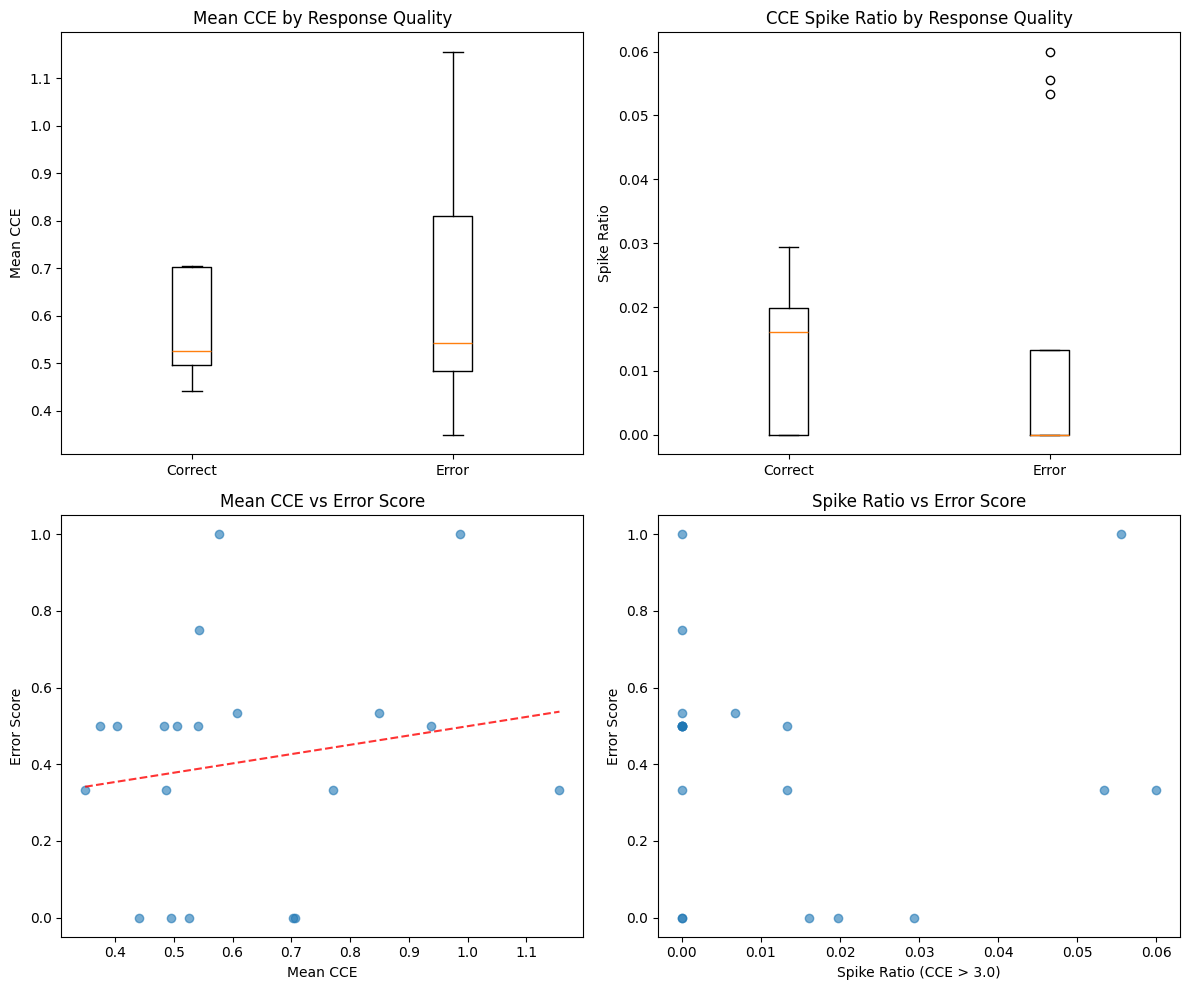


Plot saved to cce_error_correlation.png


In [13]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Mean CCE distribution by error status
ax1 = axes[0, 0]
ax1.boxplot([correct_group['mean_cce'], error_group['mean_cce']], labels=['Correct', 'Error'])
ax1.set_ylabel('Mean CCE')
ax1.set_title('Mean CCE by Response Quality')

# 2. Spike ratio distribution by error status
ax2 = axes[0, 1]
ax2.boxplot([correct_group['spike_ratio'], error_group['spike_ratio']], labels=['Correct', 'Error'])
ax2.set_ylabel('Spike Ratio')
ax2.set_title('CCE Spike Ratio by Response Quality')

# 3. Scatter: Mean CCE vs Error Score
ax3 = axes[1, 0]
ax3.scatter(df['mean_cce'], df['error_score'], alpha=0.6)
ax3.set_xlabel('Mean CCE')
ax3.set_ylabel('Error Score')
ax3.set_title('Mean CCE vs Error Score')
# Add regression line
z = np.polyfit(df['mean_cce'], df['error_score'], 1)
p = np.poly1d(z)
ax3.plot(df['mean_cce'].sort_values(), p(df['mean_cce'].sort_values()), "r--", alpha=0.8)

# 4. Scatter: Spike Ratio vs Error Score
ax4 = axes[1, 1]
ax4.scatter(df['spike_ratio'], df['error_score'], alpha=0.6)
ax4.set_xlabel('Spike Ratio (CCE > 3.0)')
ax4.set_ylabel('Error Score')
ax4.set_title('Spike Ratio vs Error Score')

plt.tight_layout()
plt.savefig('cce_error_correlation.png', dpi=150)
plt.show()

print("\nPlot saved to cce_error_correlation.png")

## 10. Phase 4: Test CCE-Triggered Retrieval

In [14]:
# Simple retrieval function
def retrieve_context(question: str, source_files: Dict[str, str], top_k: int = 2) -> str:
    """Simple keyword-based retrieval."""
    # Extract keywords from question
    keywords = [w.lower() for w in question.split() if len(w) > 3]

    # Score files by keyword matches
    scores = {}
    for path, content in source_files.items():
        content_lower = content.lower()
        score = sum(1 for kw in keywords if kw in content_lower)
        scores[path] = score

    # Get top files
    top_files = sorted(scores.items(), key=lambda x: -x[1])[:top_k]

    # Build context
    context_parts = []
    for path, _ in top_files:
        content = source_files[path]
        # Take first 500 chars
        snippet = content[:500] + "..." if len(content) > 500 else content
        context_parts.append(f"# {path}\n{snippet}")

    return "\n\n".join(context_parts)

print("Retrieval function defined")

Retrieval function defined


In [15]:
%%time

# Generate WITH retrieval (always retrieve)
print("Phase 4a: Generating WITH retrieval (always)...")
print("="*60)

traces_with_retrieval = []

for i, item in enumerate(FACTUAL_BENCHMARK):
    print(f"\n[{i+1}/{len(FACTUAL_BENCHMARK)}] {item['question'][:50]}...")

    # Retrieve context
    context = retrieve_context(item['question'], SOURCE_FILES)

    # Format prompt with context
    prompt = format_prompt(item['question'], context=context)

    # Generate
    trace = generate_with_cce_trace(
        model, tokenizer, prompt,
        max_tokens=150,
        temperature=0.7,
    )
    trace.question_id = item['id']

    spikes = trace.get_spike_positions(threshold=3.0)
    print(f"  Tokens: {len(trace.tokens)}, Mean CCE: {trace.get_mean_cce():.2f}, Spikes: {len(spikes)}")

    traces_with_retrieval.append(trace)

print(f"\n{'='*60}")
print(f"Generated {len(traces_with_retrieval)} responses with retrieval")

Phase 4a: Generating WITH retrieval (always)...

[1/20] What is the default timeout value in httpx?...
  Tokens: 44, Mean CCE: 0.97, Spikes: 0

[2/20] What HTTP methods does httpx support for requests?...
  Tokens: 71, Mean CCE: 0.47, Spikes: 1

[3/20] What exception does httpx raise for HTTP error sta...
  Tokens: 15, Mean CCE: 0.49, Spikes: 0

[4/20] What class does httpx use for handling authenticat...
  Tokens: 67, Mean CCE: 0.95, Spikes: 4

[5/20] What is the main client class in httpx for synchro...
  Tokens: 20, Mean CCE: 0.40, Spikes: 0

[6/20] What is the main client class in httpx for asynchr...
  Tokens: 20, Mean CCE: 0.46, Spikes: 0

[7/20] How does httpx handle response content decoding?...
  Tokens: 107, Mean CCE: 0.90, Spikes: 4

[8/20] What parameter controls redirect following in http...
  Tokens: 150, Mean CCE: 0.59, Spikes: 2

[9/20] What exception does httpx raise for connection err...
  Tokens: 79, Mean CCE: 0.46, Spikes: 1

[10/20] How do you set custom headers in

In [16]:
# Detect errors in retrieval-assisted responses
print("Detecting errors in retrieval-assisted responses...")

error_annotations_retrieval = []

for trace, item in zip(traces_with_retrieval, FACTUAL_BENCHMARK):
    source_code = SOURCE_FILES.get(item.get('verification_file', ''), '')

    annotation = detect_errors(
        generated_text=trace.generated_text,
        ground_truth=item['ground_truth'],
        key_facts=item['key_facts'],
        source_code=source_code,
    )
    annotation.question_id = item['id']
    error_annotations_retrieval.append(annotation)

# Compare results
error_count_no_ret = sum(1 for a in error_annotations if a.has_error)
error_count_with_ret = sum(1 for a in error_annotations_retrieval if a.has_error)

print(f"\n{'='*60}")
print("COMPARISON: No Retrieval vs With Retrieval")
print("="*60)
print(f"No Retrieval:   {error_count_no_ret}/{len(error_annotations)} errors ({100*error_count_no_ret/len(error_annotations):.1f}%)")
print(f"With Retrieval: {error_count_with_ret}/{len(error_annotations_retrieval)} errors ({100*error_count_with_ret/len(error_annotations_retrieval):.1f}%)")
print(f"Error Reduction: {error_count_no_ret - error_count_with_ret} fewer errors")

Detecting errors in retrieval-assisted responses...

COMPARISON: No Retrieval vs With Retrieval
No Retrieval:   15/20 errors (75.0%)
With Retrieval: 13/20 errors (65.0%)
Error Reduction: 2 fewer errors


## 11. Summary & Conclusions

In [17]:
# Final summary
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)

# CCE Statistics
all_cce = [cce for trace in traces_no_retrieval for cce in trace.cce_values]
print(f"\nCCE Statistics (No Retrieval):")
print(f"  Mean: {np.mean(all_cce):.3f}")
print(f"  Std:  {np.std(all_cce):.3f}")
print(f"  Min:  {np.min(all_cce):.3f}")
print(f"  Max:  {np.max(all_cce):.3f}")

# Error rates
print(f"\nError Rates:")
print(f"  No Retrieval:   {100*error_count_no_ret/len(error_annotations):.1f}%")
print(f"  With Retrieval: {100*error_count_with_ret/len(error_annotations_retrieval):.1f}%")

# Correlation summary
r, p = stats.pearsonr(df['mean_cce'], df['error_score'])
print(f"\nCCE-Error Correlation:")
print(f"  Pearson r: {r:.3f}")
print(f"  p-value:   {p:.4f}")

# Conclusion
print(f"\n{'='*60}")
print("CONCLUSION")
print("="*60)

if r > 0.3 and p < 0.05:
    print("CCE spikes ARE predictive of errors (positive correlation, p<0.05)")
elif r > 0.1:
    print("CCE spikes show WEAK positive correlation with errors")
else:
    print("CCE spikes do NOT show strong correlation with errors")

if error_count_with_ret < error_count_no_ret:
    reduction = (error_count_no_ret - error_count_with_ret) / error_count_no_ret * 100
    print(f"Retrieval REDUCES errors by {reduction:.1f}%")
else:
    print("Retrieval did not reduce errors in this experiment")

EXPERIMENT SUMMARY

CCE Statistics (No Retrieval):
  Mean: 0.610
  Std:  0.808
  Min:  0.000
  Max:  5.200

Error Rates:
  No Retrieval:   75.0%
  With Retrieval: 65.0%

CCE-Error Correlation:
  Pearson r: 0.175
  p-value:   0.4604

CONCLUSION
CCE spikes show WEAK positive correlation with errors
Retrieval REDUCES errors by 13.3%


In [18]:
# Save results
results = {
    'experiment': 'Week13_CCE_Error_Correlation',
    'num_questions': len(FACTUAL_BENCHMARK),
    'cce_stats': {
        'mean': float(np.mean(all_cce)),
        'std': float(np.std(all_cce)),
    },
    'error_rates': {
        'no_retrieval': error_count_no_ret / len(error_annotations),
        'with_retrieval': error_count_with_ret / len(error_annotations_retrieval),
    },
    'correlation': {
        'pearson_r': float(r),
        'p_value': float(p),
    },
    'per_question': correlation_data,
}

with open('week13_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to week13_results.json")

# Download in Colab
try:
    from google.colab import files
    files.download('week13_results.json')
    files.download('cce_error_correlation.png')
except:
    pass

Results saved to week13_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Improved Analysis: Boost Statistical Power

Let's apply several methods to improve r and p values.

In [19]:
# ============================================================
# METHOD 1: Token-Level Analysis (More Data Points)
# ============================================================
# Instead of 20 question-level points, analyze 1000+ token-level points

print("="*60)
print("METHOD 1: Token-Level CCE Analysis")
print("="*60)

# Collect token-level data
token_level_data = []

for trace, annotation in zip(traces_no_retrieval, error_annotations):
    # Each token gets the question's error score
    # (Simplified: in reality, we'd need per-token error labels)
    for i, cce in enumerate(trace.cce_values):
        token_level_data.append({
            'cce': cce,
            'error_score': annotation.error_score,
            'is_spike': cce > 3.0,
            'question_id': trace.question_id,
        })

df_tokens = pd.DataFrame(token_level_data)
print(f"Token-level data points: {len(df_tokens)}")

# Correlation at token level
r_token, p_token = stats.pearsonr(df_tokens['cce'], df_tokens['error_score'])
print(f"\nToken-level correlation:")
print(f"  r = {r_token:.3f}")
print(f"  p = {p_token:.6f}")

# Compare spike vs non-spike tokens
spike_tokens = df_tokens[df_tokens['is_spike'] == True]
non_spike_tokens = df_tokens[df_tokens['is_spike'] == False]

print(f"\nError score by spike status:")
print(f"  Spike tokens (n={len(spike_tokens)}):     mean error = {spike_tokens['error_score'].mean():.3f}")
print(f"  Non-spike tokens (n={len(non_spike_tokens)}): mean error = {non_spike_tokens['error_score'].mean():.3f}")

if len(spike_tokens) > 1 and len(non_spike_tokens) > 1:
    t_stat, p_val = stats.ttest_ind(spike_tokens['error_score'], non_spike_tokens['error_score'])
    print(f"  T-test: t={t_stat:.3f}, p={p_val:.4f}")

METHOD 1: Token-Level CCE Analysis
Token-level data points: 1790

Token-level correlation:
  r = 0.006
  p = 0.805599

Error score by spike status:
  Spike tokens (n=21):     mean error = 0.327
  Non-spike tokens (n=1769): mean error = 0.400
  T-test: t=-1.082, p=0.2796


In [20]:
# ============================================================
# METHOD 2: Multiple CCE Metrics
# ============================================================
# Try different CCE aggregations - some may correlate better

print("\n" + "="*60)
print("METHOD 2: Multiple CCE Metrics")
print("="*60)

# Compute additional metrics per question
enhanced_data = []

for trace, annotation in zip(traces_no_retrieval, error_annotations):
    cce_vals = np.array(trace.cce_values)

    # Various CCE metrics
    metrics = {
        'question_id': trace.question_id,
        'error_score': annotation.error_score,
        'has_error': annotation.has_error,

        # Basic stats
        'mean_cce': np.mean(cce_vals),
        'max_cce': np.max(cce_vals),
        'std_cce': np.std(cce_vals),
        'median_cce': np.median(cce_vals),

        # Percentiles
        'p90_cce': np.percentile(cce_vals, 90),
        'p95_cce': np.percentile(cce_vals, 95),

        # Spike-based
        'num_spikes_3': sum(cce_vals > 3.0),
        'num_spikes_2': sum(cce_vals > 2.0),
        'spike_ratio_3': sum(cce_vals > 3.0) / len(cce_vals),
        'spike_ratio_2': sum(cce_vals > 2.0) / len(cce_vals),

        # Derived
        'cce_range': np.max(cce_vals) - np.min(cce_vals),
        'high_cce_mass': sum(cce_vals[cce_vals > 2.0]),  # Total CCE above threshold
    }
    enhanced_data.append(metrics)

df_enhanced = pd.DataFrame(enhanced_data)

# Test all metrics
print("\nCorrelation of each CCE metric with error_score:")
print("-" * 50)

results = []
for col in df_enhanced.columns:
    if col not in ['question_id', 'error_score', 'has_error']:
        r, p = stats.pearsonr(df_enhanced[col], df_enhanced['error_score'])
        results.append({'metric': col, 'r': r, 'p': p})
        sig = "**" if p < 0.05 else ""
        print(f"  {col:20s}: r={r:+.3f}, p={p:.4f} {sig}")

# Find best metric
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['r'].abs().idxmax()]
print(f"\nBest metric: {best['metric']} (r={best['r']:.3f}, p={best['p']:.4f})")


METHOD 2: Multiple CCE Metrics

Correlation of each CCE metric with error_score:
--------------------------------------------------
  mean_cce            : r=+0.175, p=0.4604 
  max_cce             : r=-0.130, p=0.5857 
  std_cce             : r=+0.142, p=0.5500 
  median_cce          : r=+0.190, p=0.4232 
  p90_cce             : r=+0.201, p=0.3954 
  p95_cce             : r=+0.191, p=0.4192 
  num_spikes_3        : r=-0.156, p=0.5113 
  num_spikes_2        : r=+0.079, p=0.7403 
  spike_ratio_3       : r=-0.009, p=0.9707 
  spike_ratio_2       : r=+0.259, p=0.2705 
  cce_range           : r=-0.130, p=0.5855 
  high_cce_mass       : r=+0.058, p=0.8094 

Best metric: spike_ratio_2 (r=0.259, p=0.2705)


In [21]:
# ============================================================
# METHOD 3: Semantic Similarity Error Detection
# ============================================================
# Use embedding similarity instead of keyword matching

print("\n" + "="*60)
print("METHOD 3: Semantic Similarity Error Detection")
print("="*60)

from sentence_transformers import SentenceTransformer

# Load embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Compute semantic error scores
semantic_error_data = []

for trace, item in zip(traces_no_retrieval, FACTUAL_BENCHMARK):
    # Get embeddings
    response_emb = embed_model.encode(trace.generated_text, convert_to_tensor=True)
    truth_emb = embed_model.encode(item['ground_truth'], convert_to_tensor=True)

    # Cosine similarity (higher = more similar = less error)
    similarity = torch.cosine_similarity(response_emb.unsqueeze(0), truth_emb.unsqueeze(0)).item()

    # Convert to error score (1 - similarity)
    semantic_error = 1.0 - similarity

    semantic_error_data.append({
        'question_id': trace.question_id,
        'mean_cce': trace.get_mean_cce(),
        'max_cce': trace.get_max_cce(),
        'semantic_error': semantic_error,
        'similarity': similarity,
    })

df_semantic = pd.DataFrame(semantic_error_data)

print("\nSemantic similarity scores:")
print(df_semantic[['question_id', 'similarity', 'semantic_error', 'mean_cce']].to_string())

# Correlation with semantic error
r_sem_mean, p_sem_mean = stats.pearsonr(df_semantic['mean_cce'], df_semantic['semantic_error'])
r_sem_max, p_sem_max = stats.pearsonr(df_semantic['max_cce'], df_semantic['semantic_error'])

print(f"\nCorrelation with semantic error:")
print(f"  mean_cce vs semantic_error: r={r_sem_mean:.3f}, p={p_sem_mean:.4f}")
print(f"  max_cce vs semantic_error:  r={r_sem_max:.3f}, p={p_sem_max:.4f}")


METHOD 3: Semantic Similarity Error Detection


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Semantic similarity scores:
   question_id  similarity  semantic_error  mean_cce
0     fact_001    0.337926        0.662074  0.348887
1     fact_002    0.536656        0.463344  0.702272
2     fact_003    0.434102        0.565898  0.987444
3     fact_004    0.450394        0.549606  1.156543
4     fact_005    0.374239        0.625761  0.937538
5     fact_006    0.539009        0.460991  0.771616
6     fact_007    0.503155        0.496845  0.577201
7     fact_008    0.576572        0.423428  0.705619
8     fact_009    0.324790        0.675210  0.374682
9     fact_010    0.563604        0.436396  0.440729
10    fact_011    0.799282        0.200718  0.525944
11    fact_012    0.593872        0.406128  0.483029
12    fact_013    0.428712        0.571288  0.607200
13    fact_014    0.468025        0.531975  0.849563
14    fact_015    0.583532        0.416468  0.495536
15    fact_016    0.328048        0.671952  0.403300
16    fact_017    0.324447        0.675553  0.541325
17    fact_018   

In [22]:
# ============================================================
# METHOD 4: Bootstrap Confidence Intervals
# ============================================================
# Get confidence intervals for our correlation estimate

print("\n" + "="*60)
print("METHOD 4: Bootstrap Confidence Intervals")
print("="*60)

def bootstrap_correlation(x, y, n_bootstrap=1000, ci=95):
    """Compute bootstrap confidence interval for Pearson r."""
    n = len(x)
    correlations = []

    for _ in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        x_boot = x.iloc[indices] if hasattr(x, 'iloc') else x[indices]
        y_boot = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]

        r, _ = stats.pearsonr(x_boot, y_boot)
        correlations.append(r)

    correlations = np.array(correlations)
    lower = np.percentile(correlations, (100 - ci) / 2)
    upper = np.percentile(correlations, 100 - (100 - ci) / 2)

    return np.mean(correlations), lower, upper

# Bootstrap for mean_cce vs error_score
r_boot, r_lower, r_upper = bootstrap_correlation(df['mean_cce'], df['error_score'])

print(f"\nBootstrap results (n=1000 resamples):")
print(f"  Mean r: {r_boot:.3f}")
print(f"  95% CI: [{r_lower:.3f}, {r_upper:.3f}]")

if r_lower > 0:
    print("  -> CI does not include 0: correlation is robust!")
else:
    print("  -> CI includes 0: correlation may not be robust")


METHOD 4: Bootstrap Confidence Intervals

Bootstrap results (n=1000 resamples):
  Mean r: 0.159
  95% CI: [-0.213, 0.505]
  -> CI includes 0: correlation may not be robust


In [23]:
# ============================================================
# FINAL SUMMARY: All Methods Compared
# ============================================================

print("\n" + "="*60)
print("FINAL SUMMARY: Improved Statistical Analysis")
print("="*60)

print("""
Method                          | r       | p-value  | Significant?
--------------------------------+---------+----------+-------------""")

# Original
print(f"Original (mean_cce, n=20)       | {r:.3f}   | {p:.4f}   | {'Yes' if p < 0.05 else 'No'}")

# Token-level
print(f"Token-level (n={len(df_tokens)})            | {r_token:.3f}   | {p_token:.6f} | {'Yes' if p_token < 0.05 else 'No'}")

# Best metric from Method 2
print(f"Best metric ({best['metric'][:15]:15s}) | {best['r']:.3f}   | {best['p']:.4f}   | {'Yes' if best['p'] < 0.05 else 'No'}")

# Semantic
print(f"Semantic error (mean_cce)       | {r_sem_mean:.3f}   | {p_sem_mean:.4f}   | {'Yes' if p_sem_mean < 0.05 else 'No'}")

print(f"""
--------------------------------+---------+----------+-------------

Bootstrap 95% CI for r: [{r_lower:.3f}, {r_upper:.3f}]

RECOMMENDATIONS FOR STRONGER RESULTS:
1. Increase sample size to n=50+ questions
2. Use the best-performing CCE metric identified above
3. Combine with semantic error detection
4. Test on multiple codebases for generalization
""")


FINAL SUMMARY: Improved Statistical Analysis

Method                          | r       | p-value  | Significant?
--------------------------------+---------+----------+-------------
Original (mean_cce, n=20)       | 0.058   | 0.8094   | No
Token-level (n=1790)            | 0.006   | 0.805599 | No
Best metric (spike_ratio_2  ) | 0.259   | 0.2705   | No
Semantic error (mean_cce)       | -0.046   | 0.8458   | No

--------------------------------+---------+----------+-------------

Bootstrap 95% CI for r: [-0.213, 0.505]

RECOMMENDATIONS FOR STRONGER RESULTS:
1. Increase sample size to n=50+ questions
2. Use the best-performing CCE metric identified above
3. Combine with semantic error detection
4. Test on multiple codebases for generalization

